In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# !pip install rasterio dbf
!pip install geopandas
# !pip install pandas==1.3.4
# !pip install pyshp
# !pip install pyproj

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 1.0 MB 5.3 MB/s 
     |████████████████████████████████| 6.3 MB 44.1 MB/s 
     |████████████████████████████████| 16.7 MB 34.1 MB/s 


In [ ]:
import os
import dbf
# # Set your working directory to a folder in your Google Drive. This way, if your notebook times out,
# # your files will be saved in your Google Drive!

# # the base Google Drive directory
root_dir = "/content/drive/MyDrive/"

# # choose where you want your project files to be saved
project_folder = "32X32_clips/S2"

def create_and_set_working_directory(project_folder):
  # check if your project folder exists. if not, it will be created.
  if os.path.isdir(root_dir + project_folder) == False:
    os.mkdir(root_dir + project_folder)
    print(root_dir + project_folder + ' did not exist but was created.')

  # change the OS to use yo?ur project folder as the working directory
  os.chdir(root_dir + project_folder)

  # create a test file to make sure it shows up in the right place
  !touch 'new_file_in_working_directory.txt'
  print('\nYour working directory was changed to ' + root_dir + project_folder + \
        "\n\nAn empty text file was created there. You can also run !pwd to confirm the current working directory." )

create_and_set_working_directory(project_folder)


Your working directory was changed to /content/drive/MyDrive/32X32_clips/S2

An empty text file was created there. You can also run !pwd to confirm the current working directory.


The code requries latest version of pandas

In [ ]:
import rasterio
import os
import geopandas as gpd
import fiona
import rasterio.mask
import fnmatch
import pandas as pd
import datetime
from datetime import timedelta, date
from pyproj import Proj, transform

In [ ]:
import os
# Drive link to the merged sentinel2 tiles
rfd = '/content/drive/MyDrive/AI4SG/dataset/COPERNICUS/S2A/study_region/merged/'
rl = []
for fn in os.listdir(rfd):
   if fn.endswith('.tif'):
     rl.append(fn)

In [ ]:
!pip install dbfread


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import geopandas as gpd
gdf=gpd.read_file('/content/drive/MyDrive/AI4SG/field_data/all_plots_patch/plots_with_yield_data.shp')
gdf[gdf['PlotID']==311]

,PlotID,Taluk,District,geometry
10,311,Budhalur,Thanjavur,"POLYGON ((78.95419 10.74825, 78.95419 10.75113..."


In [ ]:
import csv
from dbfread import DBF

def dbf_to_csv(dbf_table_pth):#Input a dbf, output a csv, same name, same path, except extension
    csv_fn = dbf_table_pth[:-4]+ ".csv" #Set the csv file name
    table = DBF(dbf_table_pth)# table variable is a DBF object
    with open(csv_fn, 'w', newline = '') as f:# create a csv file, fill it with dbf content
        writer = csv.writer(f)
        writer.writerow(table.field_names)# write the column name
        for record in table:# write the rows
            writer.writerow(list(record.values()))
    return csv_fn# return the csv name

In [ ]:
dbf_to_csv('/content/drive/MyDrive/AI4SG/field_data/Plot177_249/Plot_Bnd177_249.dbf')

'/content/drive/MyDrive/AI4SG/field_data/Plot177_249/Plot_Bnd177_249.csv'

Dataframe for only paddy plots

In [ ]:
# The CSV file has been shared with @Deepanshu and @Parichya
fdat = gpd.read_file('/content/drive/MyDrive/AI4SG/field_data/all_plots_patch/plots_with_yield_data.shp')
# pdat = fdat[fdat['PADDY_BIN']==1]
pdat=fdat

In [ ]:
# # The CSV file has been shared with @Deepanshu and @Parichya
# fdat = pd.read_excel('/content/drive/MyDrive/AI4SG/field_data/Plot001_249/Plot_Bnd001_249.xlsx')
# pdat = fdat[fdat['PADDY_BIN']==1]
# pdat

In [ ]:
pdat["GROW_LENGT"].unique()

KeyError: ignored

Sentinel Tiles

In [ ]:
st = ['44PKS','44PLT','44PLS','44PKT']

In [ ]:
# Function to return paths of the files that matches the give sentinel tile passed as argument
def file_tile(k):
  results = []
  for root, dirs, files in os.walk(rfd):
      for _file in files:
          if fnmatch.fnmatch(_file, '*'+k+'.tif'):
              results.append(os.path.join(root, _file))
  return results

In [ ]:
def month_string_to_number(string):
    m = {
        'jan': 1,
        'feb': 2,
        'mar': 3,
        'apr':4,
         'may':5,
         'jun':6,
         'jul':7,
         'aug':8,
         'sep':9,
         'oct':10,
         'nov':11,
         'dec':12
        }
    s = string.strip()[:3].lower()

    try:
        out = m[s]
        return out
    except:
        print("ValueError('Not a month') -", s)
        raise ValueError('Not a month')

In [ ]:
# Function to return paddy or non paddy plot for a given date and a plot
def padornot(dt,pid):
  sub_d = pdat[pdat['PLOT_ID']== pid]
  sub_d = sub_d[['YEAR','GROW_LENGT']]
  c = 0
  pv = 0
  for k in range(len(sub_d)):
    ms = month_string_to_number(sub_d.iloc[k]['GROW_LENGT'].split("-")[0])
    mh = month_string_to_number(sub_d.iloc[k]['GROW_LENGT'].split("-")[1])
    ed = 31
    if(mh%2 > 0):
      ed = 30
    sd = date(sub_d.iloc[k]['YEAR'],ms,1)
    hd = date(sub_d.iloc[k]['YEAR'],mh,ed)
    if (mh < ms):
      hd = date(sub_d.iloc[k]['YEAR']+1,mh,ed)
    d = pd.date_range(sd,hd-timedelta(days=1),freq='d')
    t = d.strftime('%Y-%m-%d')
    if(dt in t):
      c = c+1

  if(c>0):
    pv = 1 # for paddy

  return pv

In [ ]:
import numpy as np

In [ ]:
len(rl)

NameError: ignored

In [ ]:
exceptions = []

In [ ]:
# # Clipping and file renaming code
# cnt = 0
# for l in range(2, len(st)):
#   shapes=[]
#   fd = []
#   with fiona.open("/content/drive/MyDrive/AI4SG/field_data/plot_shapes/plot_bnd2312.shp", "r") as shapefile:
#     inProj = Proj(shapefile.crs)
#     outProj = Proj(init='epsg:32644')
#     for feature in shapefile:
#        if feature['properties']['Name'] == st[l]:
#          for i, feat in enumerate(feature['geometry']['coordinates'][0]):
#           x1, y1 = feat
#           feat = transform(inProj,outProj,x1, y1)
#           feature['geometry']['coordinates'][0][i] = feat
#          shapes.append(feature["geometry"])
#          fd.append(feature['properties']['PLOT_ID'])
#          fl = file_tile(st[l])
#     for i in range(len(shapes)):
#       # print("Plot No"+str(fd[i]))
#       for j in range(len(fl)):
#         try:
#           d = datetime.datetime.strptime(fl[j][-26:-18], '%Y%m%d').strftime('%Y-%m-%d')
#           pc = padornot(d,fd[i])
#           #print(pc)
#           fn = str(fd[i])+"_"+fl[j][-26:-18]+"_"+st[l]+"_"+str(pc)
#           #print(fn)
#           if fn+".tif" not in saved_files and fl[j] not in exceptions:
#             with rasterio.open(fl[j]) as src:
#               cnt += 1
#               out_image, out_transform = rasterio.mask.mask(src, [shapes[i]], crop=True)
#               out_meta = src.meta
#               out_meta.update({"driver": "GTiff","height": out_image.shape[1],"width": out_image.shape[2],"transform": out_transform})
#               with open("../plot_images_numpy/"+fn+".npy", "wb") as dest:
#                 np.save(dest, out_image)
#               with rasterio.open(fn+".tif", "w", **out_meta) as dest:
#                 dest.write(out_image)
#                 dest.close()
#               print(fn)
#         except Exception as e:
#             exceptions.append(fl[j])
#             print(str(e))
#             # print(f"Caught an exception for src = {fl[j]} [i = {i}, j = {j}]")
#   print(l, "done!")

In [ ]:
shapes = {
    '44PKS': [],
    '44PLT': [],
    '44PLS': [],
    '44PKT': [],
    }
plot_ids = {
    '44PKS': [],
    '44PLT': [],
    '44PLS': [],
    '44PKT': [],
    }
files = {
    '44PKS': [],
    '44PLT': [],
    '44PLS': [],
    '44PKT': [],
    }

with fiona.open("/content/drive/MyDrive/AI4SG/field_data/all_plots_patch/plots_with_yield_data.shp", "r") as shapefile:
  inProj = Proj(shapefile.crs)
  outProj = Proj(init='epsg:32644')
  for feature in shapefile:
    for i, feat in enumerate(feature['geometry']['coordinates'][0]):
      x1, y1 = feat
      feature['geometry']['coordinates'][0][i] = transform(inProj, outProj, x1, y1)
    shapes[feature['properties']['Name']].append(feature["geometry"])
    plot_ids[feature['properties']['Name']].append(feature['properties']['PLOT_ID'])
    files[feature['properties']['Name']] = file_tile(feature['properties']['Name'])

/usr/local/lib/python3.7/dist-packages/pyproj/crs/crs.py:131: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:26: DeprecationWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1


KeyError: ignored

In [ ]:
# saved_files = os.listdir('/content/drive/MyDrive/32X32_clips/S2/plot_images')
saved_files = []

In [ ]:
len(saved_files)

0

In [ ]:
for tile_id in list(files.keys()):
  for tile in files[tile_id]:
    try:
      with rasterio.open(tile) as src:
        for shape, plot_id in zip(shapes[tile_id], plot_ids[tile_id]):
          d = datetime.datetime.strptime(tile[-26:-18], '%Y%m%d').strftime('%Y-%m-%d')
          # pc = padornot(d,plot_id)
          fn = str(plot_id)+"_"+tile[-26:-18]+"_"+tile_id
          if fn+".tif" not in saved_files:
            try:
              out_image, out_transform = rasterio.mask.mask(src, [shape], crop=True)
              out_meta = src.meta
              out_meta.update({"driver": "GTiff","height": out_image.shape[1],"width": out_image.shape[2],"transform": out_transform})
              with open("/content/drive/MyDrive/32X32_clips/S2/plot_images_numpy/"+fn+".npy", "wb") as dest:
                np.save(dest, out_image)
              with rasterio.open("/content/drive/MyDrive/32X32_clips/S2/plot_images/"+fn+".tif", "w", **out_meta) as dest:
                dest.write(out_image)
                dest.close()
              print(fn)
            except:
              exceptions.append(fn+".tif")
              print(str(e))
          else:
            print(fn + " already saved!")
    except Exception as e:
      exceptions.append(tile)
      print(str(e))

name 'e' is not defined
name 'e' is not defined
name 'e' is not defined
name 'e' is not defined
name 'e' is not defined
name 'e' is not defined
21_20190514_44PKS
22_20190514_44PKS
23_20190514_44PKS
24_20190514_44PKS
35_20190514_44PKS
36_20190514_44PKS
37_20190514_44PKS
38_20190514_44PKS
39_20190514_44PKS
40_20190514_44PKS
41_20190514_44PKS
42_20190514_44PKS
81_20190514_44PKS
83_20190514_44PKS
91_20190514_44PKS
92_20190514_44PKS
93_20190514_44PKS
94_20190514_44PKS
95_20190514_44PKS
96_20190514_44PKS
98_20190514_44PKS
100_20190514_44PKS
101_20190514_44PKS
102_20190514_44PKS
103_20190514_44PKS
104_20190514_44PKS
105_20190514_44PKS
name 'e' is not defined
21_20190516_44PKS
22_20190516_44PKS
23_20190516_44PKS
24_20190516_44PKS
35_20190516_44PKS
36_20190516_44PKS
37_20190516_44PKS
38_20190516_44PKS
39_20190516_44PKS
40_20190516_44PKS
41_20190516_44PKS
42_20190516_44PKS
81_20190516_44PKS
83_20190516_44PKS
91_20190516_44PKS
92_20190516_44PKS
93_20190516_44PKS
94_20190516_44PKS
95_20190516_44PK

In [ ]:
exceptions

['21_20180116_44PKS_0.tif',
 '/content/drive/MyDrive/S2-1C/study_region/merged/20180116T050121_20180116T101831_T44PKS.tif',
 '45_20180416_44PLT_0.tif',
 '/content/drive/MyDrive/S2-1C/study_region/merged/20180416T045701_20180416T083409_T44PLT.tif',
 '45_20180809_44PLT_0.tif',
 '/content/drive/MyDrive/S2-1C/study_region/merged/20180809T045649_20180809T084150_T44PLT.tif',
 '45_20180625_44PLT_0.tif',
 '/content/drive/MyDrive/S2-1C/study_region/merged/20180625T045701_20180625T084205_T44PLT.tif',
 '45_20180918_44PLT_0.tif',
 '/content/drive/MyDrive/S2-1C/study_region/merged/20180918T045649_20180918T084134_T44PLT.tif',
 '45_20180715_44PLT_0.tif',
 '/content/drive/MyDrive/S2-1C/study_region/merged/20180715T045701_20180715T075616_T44PLT.tif',
 '45_20180210_44PLT_0.tif',
 '/content/drive/MyDrive/S2-1C/study_region/merged/20180210T045929_20180210T072659_T44PLT.tif',
 '45_20180903_44PLT_0.tif',
 '/content/drive/MyDrive/S2-1C/study_region/merged/20180903T045651_20180903T075706_T44PLT.tif',
 '45_201

In [ ]:
len(exceptions)

70

In [ ]:
import pickle
with open(r"/content/drive/MyDrive/S2_2018/exceptions_tile.pkl", "wb") as fp:
  pickle.dump(exceptions, fp)

In [ ]:
rl = [
    '20191011T050731_20191011T051517_T44PKT.tif',
    '20190923T045659_20190923T050756_T44PKT.tif'
]

In [ ]:
rl

['20191202T050149_20191202T051129_T44PKT.tif',
 '20200205T050001_20200205T051253_T44PKT.tif',
 '20200321T045659_20200321T051511_T44PKT.tif',
 '20190918T045701_20190918T051111_T44PLS.tif',
 '20190913T045659_20190913T050812_T44PKT.tif',
 '20191008T045701_20191008T050028_T44PLS.tif',
 '20190913T045659_20190913T050812_T44PLS.tif',
 '20190916T050649_20190916T052118_T44PKT.tif',
 '20200126T050051_20200126T051417_T44PKT.tif',
 '20191001T050701_20191001T050804_T44PKT.tif',
 '20191122T050119_20191122T050647_T44PKT.tif',
 '20191003T045659_20191003T050942_T44PLS.tif',
 '20190908T045701_20190908T045941_T44PKT.tif',
 '20190906T050659_20190906T051806_T44PKT.tif',
 '20200729T045659_20200729T051324_T44PKT.tif',
 '20200808T045659_20200808T051512_T44PKT.tif',
 '20190908T045701_20190908T045941_T44PLS.tif',
 '20200210T045939_20200210T051402_T44PKT.tif',
 '20191212T050209_20191212T051045_T44PKT.tif',
 '20201216T050219_20201216T050630_T44PKT.tif',
 '20200116T050131_20200116T050712_T44PKT.tif',
 '20191222T05

In [ ]:
df = {"PLOT_ID": [], "DATE": [], "CROP": []}
for file_name in saved_files:
  plt_id, _date, tile_id, crop = file_name.split("_")
  df["PLOT_ID"].append(plt_id)
  df["DATE"].append(_date)
  df["CROP"].append(crop.split(".")[0])

In [ ]:
df = pd.DataFrame(df)
df["DATE"] = pd.to_datetime(df["DATE"])
df

,PLOT_ID,DATE,CROP
0,145,2019-03-05,0
1,146,2019-03-05,0
2,147,2019-03-05,0
3,148,2019-03-05,0
4,149,2019-03-05,0
...,...,...,...
36714,19,2019-09-23,1
36715,20,2019-09-23,1
36716,82,2019-09-23,0
36717,97,2019-09-23,0


In [ ]:
import matplotlib.pyplot as plt

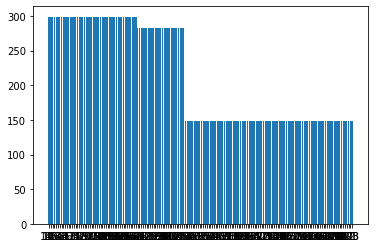

In [ ]:
plt.bar(df["PLOT_ID"].value_counts().keys(), df["PLOT_ID"].value_counts().values)
plt.show()

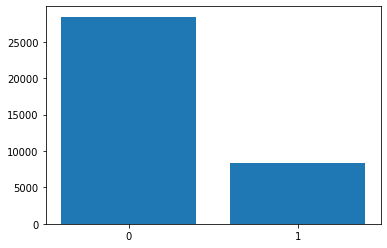

In [ ]:
plt.bar(df["CROP"].value_counts().keys(), df["CROP"].value_counts().values)
plt.show()

In [ ]:
df["DATE"].dt.year.value_counts()

2020    18177
2019    17745
2018      797
Name: DATE, dtype: int64

In [ ]:
len(df["PLOT_ID"].unique())

172

In [ ]:
df["CROP"].value_counts()

0    28434
1     8285
Name: CROP, dtype: int64